# Netflix Content Analysis

This project explores the Netflix Movies and TV Shows dataset sourced from Kaggle, 
containing titles available on Netflix up to 2021. The dataset includes information 
such as title, director, cast, country, date added, release year, rating, duration, 
and genre. The goal is to analyze Netflix's content library and uncover meaningful 
patterns around content growth, geographic distribution, and viewing demographics.

In [179]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [180]:
#load and show dataset 
df = pd.read_csv('Netflix_dataset.csv')
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,1-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [181]:
#check first five rows and make a copy of dataset to work with
df_copy = df.copy()
df_copy.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [182]:
#Info on dataset
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [183]:
#Check missing values
df_copy.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [184]:
df_copy.duplicated().sum()

np.int64(0)

In [185]:
# Replacing NaN values in 'director' column with 'Unknown'
df_copy['director'] = df_copy['director'].fillna('Unknown')

# Replacing NaN values in 'cast' column with 'Various'
df_copy['cast'] = df_copy['cast'].fillna('Various')

# Filling missing rating value with "Not Rated"
df_copy['rating'] = df_copy['rating'].fillna('Not Rated')

print(f"Verifying changes:\Director:{df_copy['director'].unique()}\Cast:{df_copy['cast'].unique()}\nRating:{df_copy['rating'].unique()}")

Verifying changes:\Director:['Kirsten Johnson' 'Unknown' 'Julien Leclercq' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']\Cast:['Various'
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng'
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'
 ...
 'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf'
 'Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers'
 'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna Malik, Malkeet Rauni, Anita Shabdish, Chittaranjan Tripathy']
Rating:['PG-13' 'TV-MA' 'PG' 

In [186]:
df_copy["release_year"] = pd.to_numeric(df_copy["release_year"], errors="coerce").astype("Int64")
df_copy.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     Int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

## Analysis
The following section answers key business questions about Netflix's content library through visualizations and insights.

### Q1. How has Netflix content volume changed over the years?

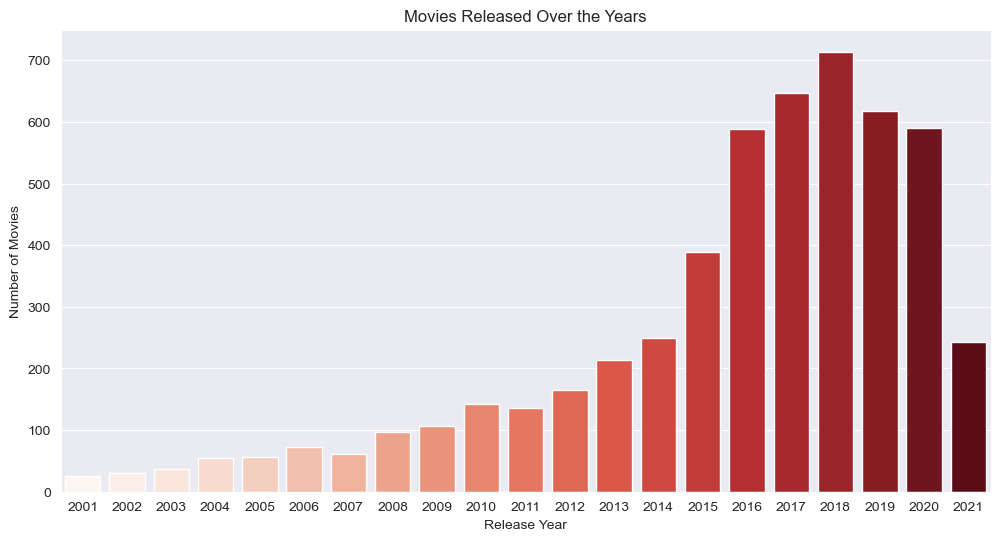

In [197]:
movies_filter = df_copy[df_copy["release_year"] > 2000]
movies = movies_filter.groupby("release_year")["title"].count().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")
sns.barplot(data=movies, x="release_year", y="title", palette="Reds",hue='release_year',legend=False)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Over the Years")
plt.show()

**Insight:** Netflix content grew steadily from 2001, with a sharp rise starting 
around 2015. Content additions peaked in 2018, followed by a slight decline toward 
2021 likely reflecting the impact of COVID-19 on production pipelines.

### Q2. Which countries contribute the most content to Netflix?

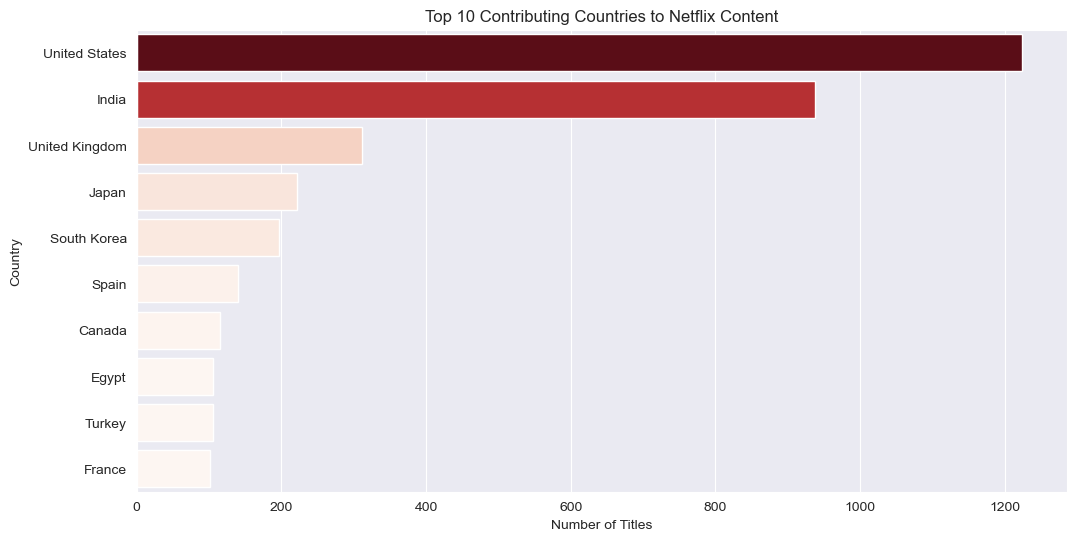

In [196]:
countries = df_copy.explode('country').groupby('country')['title'].count().reset_index()
countries = countries.sort_values(by="title", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=countries['country'], x=countries['title'], palette="Reds",hue=countries['title'],legend=False)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.title("Top 10 Contributing Countries to Netflix Content")
plt.show()

**Insight:** The United States dominates Netflix's content library by a significant 
margin, followed by India and the United Kingdom. This reflects Netflix's heavy 
investment in American content alongside its aggressive expansion into the Indian 
market in recent years.

### Q3. Which directors have the most titles on Netflix?

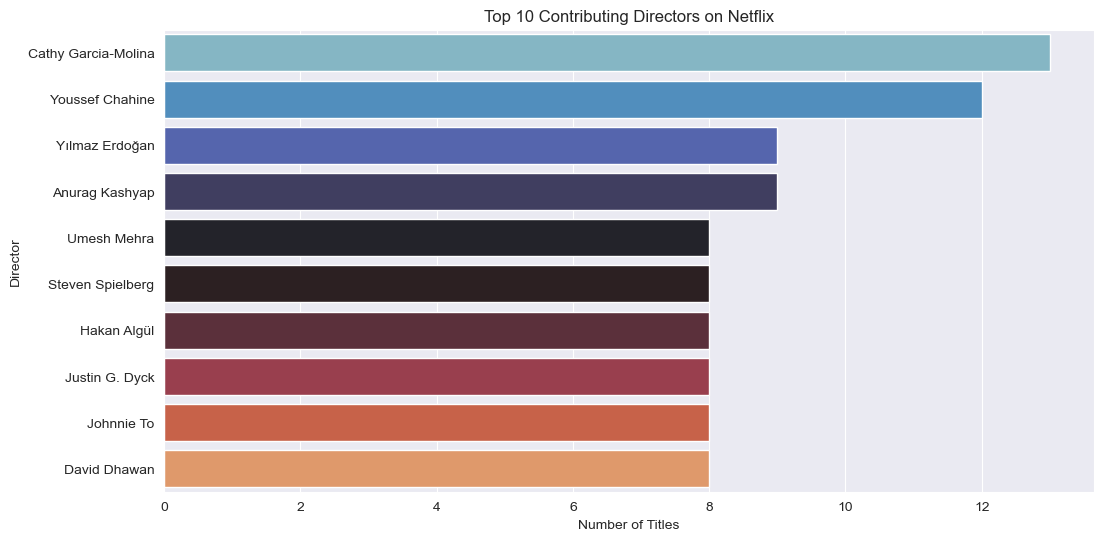

In [199]:
directors = df_copy['director'].str.split(',').explode().str.strip()

# Count titles per director, remove Unknown, keep top 10
directors = directors[directors != 'Unknown'].value_counts().reset_index()
directors.columns = ['director', 'count']
directors = directors.head(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(y=directors['director'], x=directors['count'], palette="icefire", hue=directors['director'], legend=False)
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.title("Top 10 Contributing Directors on Netflix")
plt.show()

**Insight:** Cathy Garcia-Molina leads with 12 titles, followed closely by Youssef 
Chahine with 12. Notably the list is internationally diverse — featuring directors 
from Philippines, Egypt, Turkey, India and beyond — reflecting Netflix's global 
content strategy.

C:\Users\hp\AppData\Local\Temp\ipykernel_23308\988561123.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_copy['date_added'] = pd.to_datetime(df_copy['date_added'])


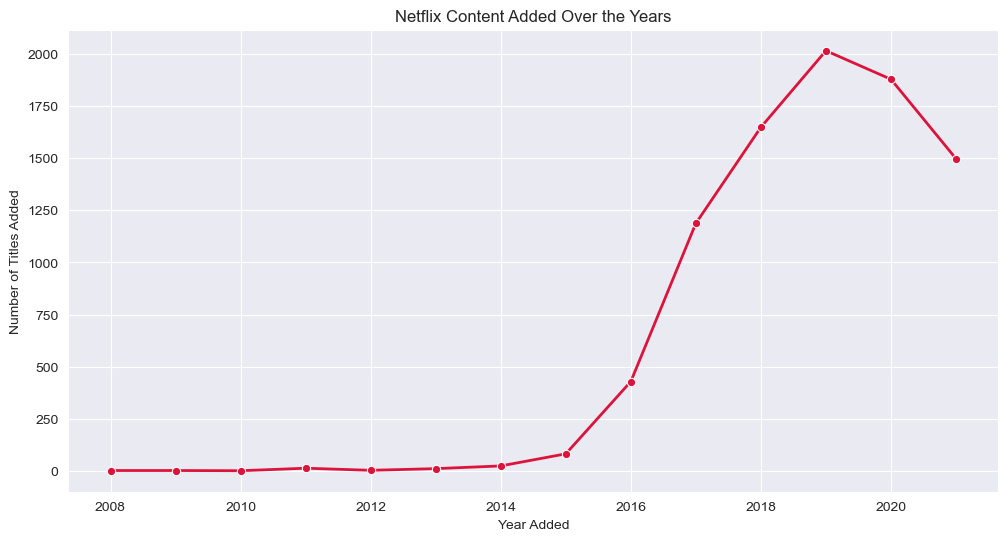

In [190]:
# Visualizing Netflix Content Added Over the Years
df_copy['date_added'] = pd.to_datetime(df_copy['date_added'])
df_copy['year_added'] = df_copy['date_added'].dt.year
df_copy["year_added"] = pd.to_numeric(df_copy["year_added"], errors="coerce").astype("Int64")

content_per_year = df_copy.groupby('year_added')['title'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("darkgrid")
sns.lineplot(data=content_per_year, x='year_added', y='title', marker="o", linewidth=2, color='crimson')

plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.title("Netflix Content Added Over the Years")
plt.show()


In [191]:
df_copy = df_copy.dropna(subset=["listed_in"])  
df_copy["type"] = df_copy["listed_in"].apply(
    lambda x: "Movie" if "Movies" in x else "TV Show" if "TV Shows" in x else None
)
df_copy = df_copy.dropna(subset=["type"])
df_copy["type"].value_counts()

df_copy["duration"] = df_copy["duration"].str.extract(r'(\d+)')
df_copy["duration"] = pd.to_numeric(df_copy["duration"], errors="coerce").astype("Int64")

C:\Users\hp\AppData\Local\Temp\ipykernel_23308\4100537932.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies, y="duration", ax=axes[0], palette="bright",legend=False)


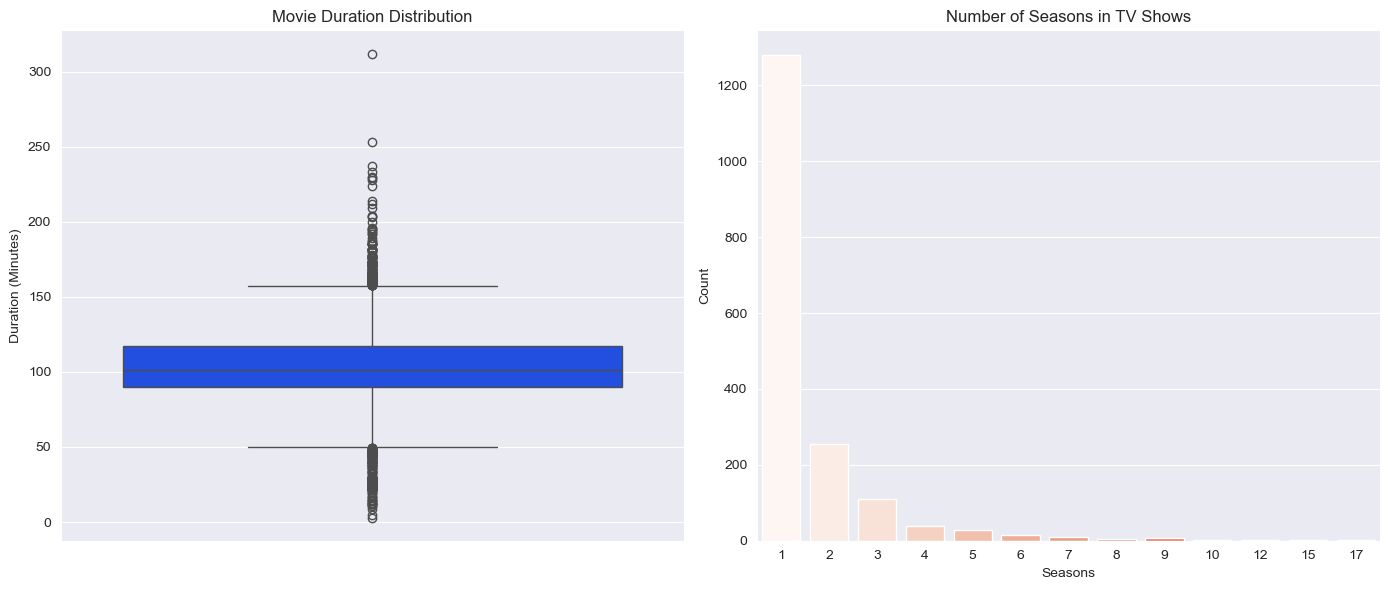

In [192]:
# Splitting Movies and TV Shows
movies = df_copy[df_copy["type"] == "Movie"]
tv_shows = df_copy[df_copy["type"] == "TV Show"]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Movies - Duration in minutes
sns.boxplot(data=movies, y="duration", ax=axes[0], palette="bright",legend=False)
axes[0].set_title("Movie Duration Distribution")
axes[0].set_ylabel("Duration (Minutes)")

# TV Shows - Duration in seasons
sns.countplot(data=tv_shows, x="duration", ax=axes[1], palette="Reds",hue='duration',legend=False)
axes[1].set_title("Number of Seasons in TV Shows")
axes[1].set_xlabel("Seasons")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Distribution of Content Ratings on Netflix')

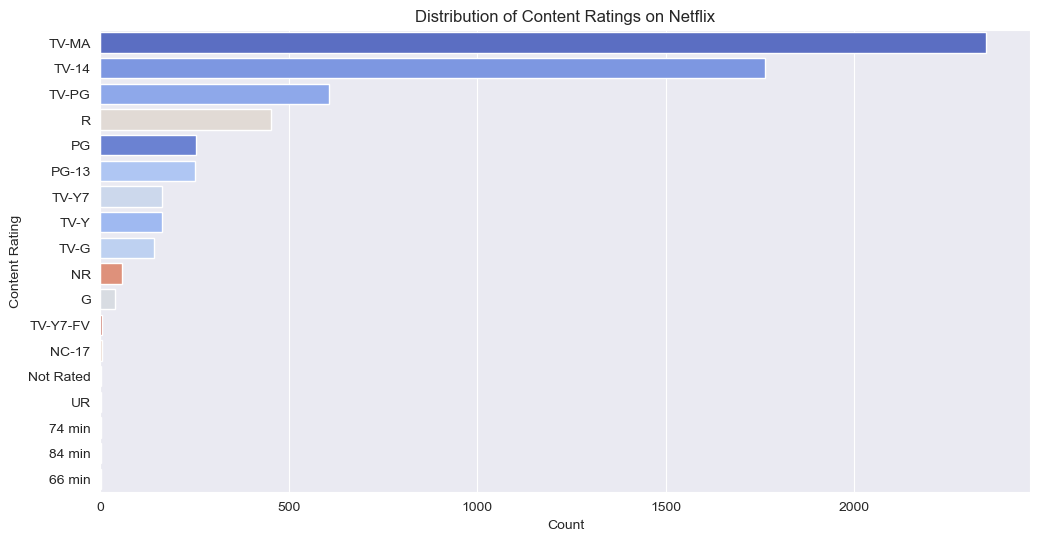

In [193]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_copy, y="rating", order=df_copy["rating"].value_counts().index, palette="coolwarm",hue='rating',legend=False)
plt.xlabel("Count")
plt.ylabel("Content Rating")
plt.title("Distribution of Content Ratings on Netflix")

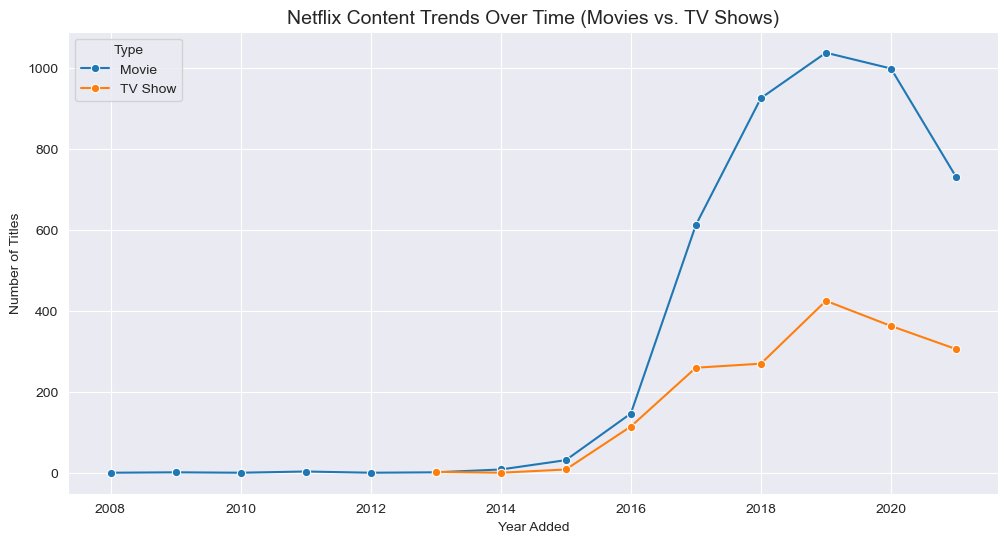

In [194]:
content_trend = df_copy.groupby(["year_added", "type"])["title"].count().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=content_trend, x="year_added", y="title", hue="type", marker="o")

plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Trends Over Time (Movies vs. TV Shows)", fontsize=14)
plt.legend(title="Type")
plt.show()


In [195]:
df_copy = df_copy.dropna()  # Removes all rows with NaN values
df_copy.to_csv("Cleaned_Netflix_data.csv", index=False)
print("File successfully created without NaN values!")

File successfully created without NaN values!
